In [1]:
from hossam import load_data
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from scipy.spatial import ConvexHull
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull

my_dpi = 200


In [2]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [3]:
origin = load_data("iris")
origin.head()

1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

field         description
------------  -------------
Sepal.Length  꽃밭침 길이
Sepal.Width   꽃밭침 너비
Petal.Length  꽃잎 길이
Petal.Width   꽃잎 너비
Species       품종



,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 📝[3]데이터 전처리

In [8]:
df = origin.copy()
df.drop("Species", axis=1, inplace=True)
df.head()



,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## ✏️2~19까지 군집의 수를 늘려가면서 Interia 값 수집<br>
estimaor.interia_ 사용

In [25]:
klist = list(range(2,11))
interia =[]
# interia값을 저장할 리스트

for k in klist:
    estimator=KMeans(n_clusters=k, random_state=0)
    estimator.fit(X=df)
    interia.append(estimator.inertia_)
interia


[152.34795176035792,
 78.85566582597731,
 57.228473214285714,
 49.82774055829229,
 42.42154575309748,
 34.420191786283894,
 30.064593073593073,
 28.715856536394462,
 27.462118791296422]

## ✏️(2)Interia 값의 변화 시각화

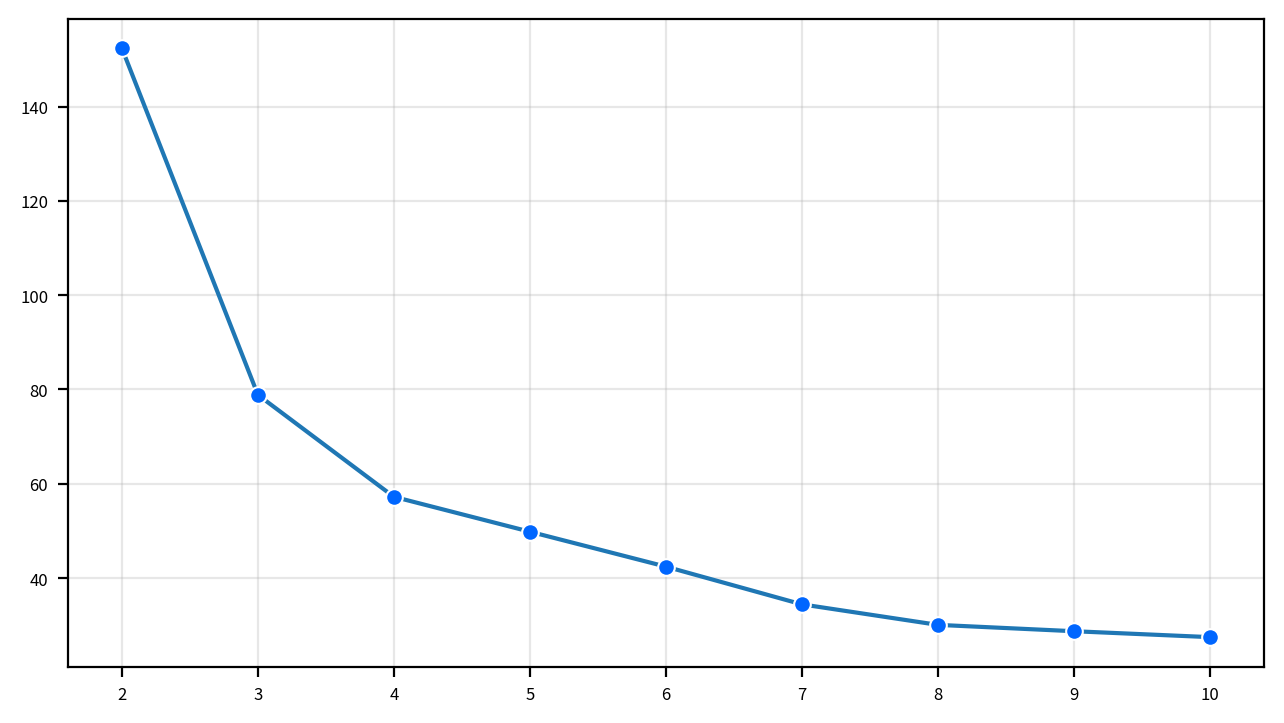

In [28]:
# 그래프 크기 설정
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=figsize,
    dpi=my_dpi
)

# -------------------------------
# LinePlot 그리기
# -------------------------------
sb.lineplot(
    x=klist,
    y=interia,
    linestyle="-",
    marker="o",
    markerfacecolor="#0066ff",
    markeredgecolor="#ffffff"
)

# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
plt.close()


 >  인사이트<br>
x축의 값이 4인 지점부터 감소가 완만하게 진행되는 것으로 보인다. 그러므로 최적의 클러스터 수는 3을 ㅗ판단할 수 있다.